# Loan Dataset: Data Acquisition, Cleaning & Visualisation
**Dataset:** Kaggle - *Loan Prediction Problem Dataset* (`train_u6lujuX_CVtuI9i.csv`)
Download it from kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset, then upload the CSV in Step 1.

## Step 1: Data acquisition (upload the CSV)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

sns.set_theme(style="whitegrid")

# If files are not already uploaded, prompt the user
try:
    df = pd.read_csv("train_u6lujuX_CVtuZ9i.csv")
    print("Loaded train_u6lujuX_CVtuZ9i.csv from environment.")
except FileNotFoundError:
    uploaded = files.upload()
    if "train_u6lujuX_CVtuZ9i.csv" in uploaded:
        df = pd.read_csv("train_u6lujuX_CVtuZ9i.csv")
    else:
        df = pd.read_csv(list(uploaded.keys())[0])

print("Rows, Columns:", df.shape)
df.head()

Saving train_u6lujuX_CVtuZ9i.csv to train_u6lujuX_CVtuZ9i.csv
Rows, Columns: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Step 2: First look at the data

In [ ]:
df.info()
print("\nDuplicate rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB

Duplicate rows: 0


## Step 3: Missing-value visualisation

,Missing,Percent
Credit_History,50,8.14
Self_Employed,32,5.21
LoanAmount,22,3.58
Dependents,15,2.44
Loan_Amount_Term,14,2.28
Gender,13,2.12
Married,3,0.49


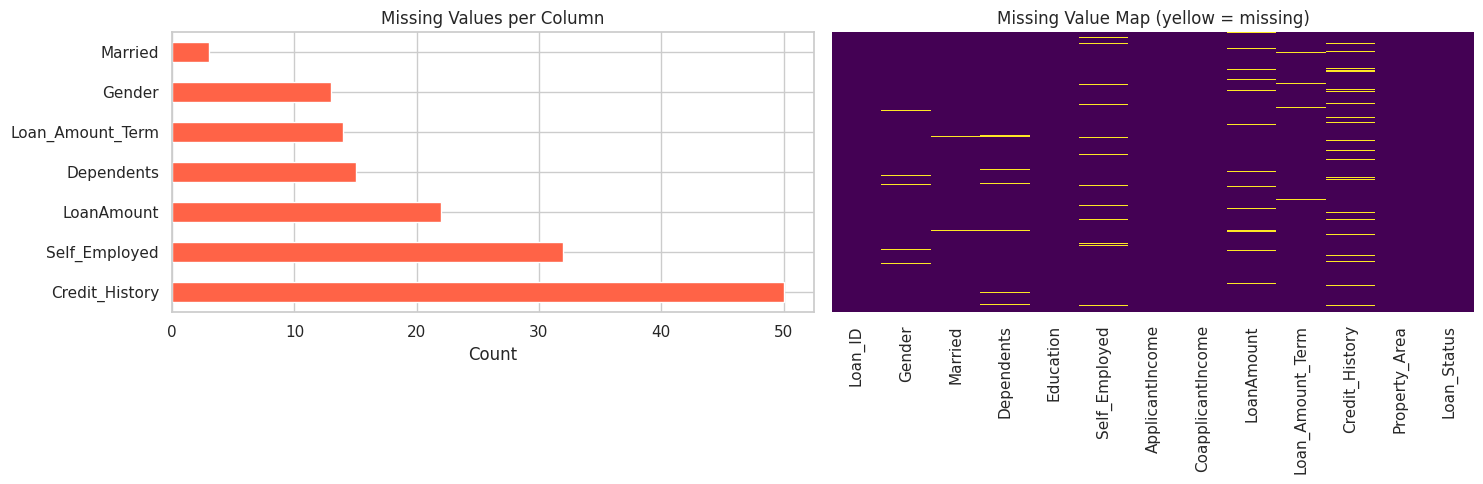

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({"Missing": missing, "Percent": missing_pct})
missing_table = missing_table[missing_table["Missing"] > 0].sort_values("Missing", ascending=False)
display(missing_table)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart of missing counts
missing_table["Missing"].plot(kind="barh", color="tomato", ax=ax[0])
ax[0].set_title("Missing Values per Column")
ax[0].set_xlabel("Count")

# Heatmap: each yellow line is a missing cell
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False, ax=ax[1])
ax[1].set_title("Missing Value Map (yellow = missing)")

plt.tight_layout()
plt.show()

## Step 4: Data cleaning

In [ ]:
clean = df.copy()

# 1. Remove duplicates and the ID column (not useful for analysis)
clean = clean.drop_duplicates()
clean = clean.drop(columns=["Loan_ID"])

# 2. Fix data type issue: Dependents has the value '3+'
clean["Dependents"] = clean["Dependents"].replace("3+", "3")

# 3. Fill missing values
num_cols = clean.select_dtypes(include="number").columns
cat_cols = clean.select_dtypes(exclude="number").columns

for col in num_cols:
    clean[col] = clean[col].fillna(clean[col].median())     # numbers -> median
for col in cat_cols:
    clean[col] = clean[col].fillna(clean[col].mode()[0])    # text -> most common value

clean["Dependents"] = clean["Dependents"].astype(int)

# 4. Create a new useful column
clean["TotalIncome"] = clean["ApplicantIncome"] + clean["CoapplicantIncome"]

# 5. Treat outliers (cap values using the IQR rule)
for col in ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "TotalIncome"]:
    q1, q3 = clean[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    clean[col] = clean[col].clip(q1 - 1.5 * iqr, q3 + 1.5 * iqr)

print("Missing values after cleaning:", clean.isnull().sum().sum())
print("Shape after cleaning:", clean.shape)
clean.head()

Missing values after cleaning: 0
Shape after cleaning: (614, 13)


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
0,Male,No,0,Graduate,No,5849.0,0.0,128.0,360.0,1.0,Urban,Y,5849.0
1,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural,N,6091.0
2,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.0,360.0,1.0,Urban,Y,3000.0
3,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1.0,Urban,Y,4941.0
4,Male,No,0,Graduate,No,6000.0,0.0,141.0,360.0,1.0,Urban,Y,6000.0


## Step 5: Statistical summaries

In [ ]:
print("=== Numerical summary ===")
display(clean.describe().T.round(2))

print("\n=== Categorical summary ===")
display(clean.describe(include="object").T)

print("\n=== Skewness of numeric columns ===")
display(clean[["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "TotalIncome"]].skew().round(2))

if "Loan_Status" in clean.columns:
    print("\n=== Loan approval counts ===")
    display(clean["Loan_Status"].value_counts())

    print("\n=== Average income and loan amount by loan status ===")
    display(clean.groupby("Loan_Status")[["TotalIncome", "LoanAmount"]].mean().round(1))
else:
    print("\n=== Loan_Status column not found in this dataset ===")
    print("Note: You loaded the test set which doesn't have labels. Please upload/read the train set to see approval counts.")

=== Numerical summary ===


,count,mean,std,min,25%,50%,75%,max
Dependents,614.0,0.74,1.01,0.0,0.00,0.0,1.00,3.00
ApplicantIncome,614.0,4617.11,2479.85,150.0,2877.50,3812.5,5795.00,10171.25
CoapplicantIncome,614.0,1419.70,1624.61,0.0,0.00,1188.5,2297.25,5743.12
LoanAmount,614.0,137.37,55.78,9.0,100.25,128.0,164.75,261.50
Loan_Amount_Term,614.0,342.41,64.43,12.0,360.00,360.0,360.00,480.00
Credit_History,614.0,0.86,0.35,0.0,1.00,1.0,1.00,1.00
TotalIncome,614.0,6194.72,2875.79,1442.0,4166.00,5416.5,7521.75,12555.38



=== Categorical summary ===


,count,unique,top,freq
Gender,614,2,Male,502
Married,614,2,Yes,401
Education,614,2,Graduate,480
Self_Employed,614,2,No,532
Property_Area,614,3,Semiurban,233
Loan_Status,614,2,Y,422



=== Skewness of numeric columns ===


,0
ApplicantIncome,1.04
CoapplicantIncome,1.01
LoanAmount,0.68
TotalIncome,0.94



=== Loan approval counts ===


,count
Loan_Status,
Y,422
N,192



=== Average income and loan amount by loan status ===


,TotalIncome,LoanAmount
Loan_Status,,
N,6185.3,141.3
Y,6199.0,135.6


## Step 6: Charts to communicate patterns

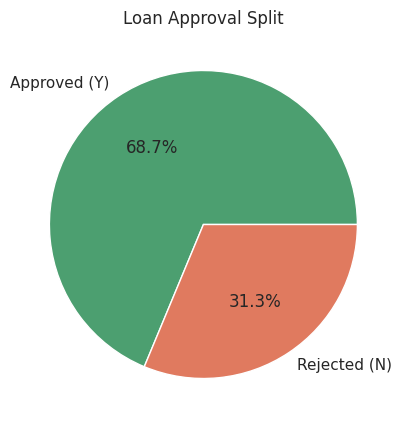

In [ ]:
# Chart 1: Loan approval split
if "Loan_Status" in clean.columns:
    plt.figure(figsize=(5, 5))
    clean["Loan_Status"].value_counts().plot(kind="pie", autopct="%1.1f%%", colors=["#4c9f70", "#e07a5f"],
                                             labels=["Approved (Y)", "Rejected (N)"])
    plt.title("Loan Approval Split")
    plt.ylabel("")
    plt.show()
else:
    print("Error: 'Loan_Status' column not found in the cleaned dataset.")
    print("Please go back and re-run Step 4 (Data cleaning) to update your 'clean' variable with the training data.")

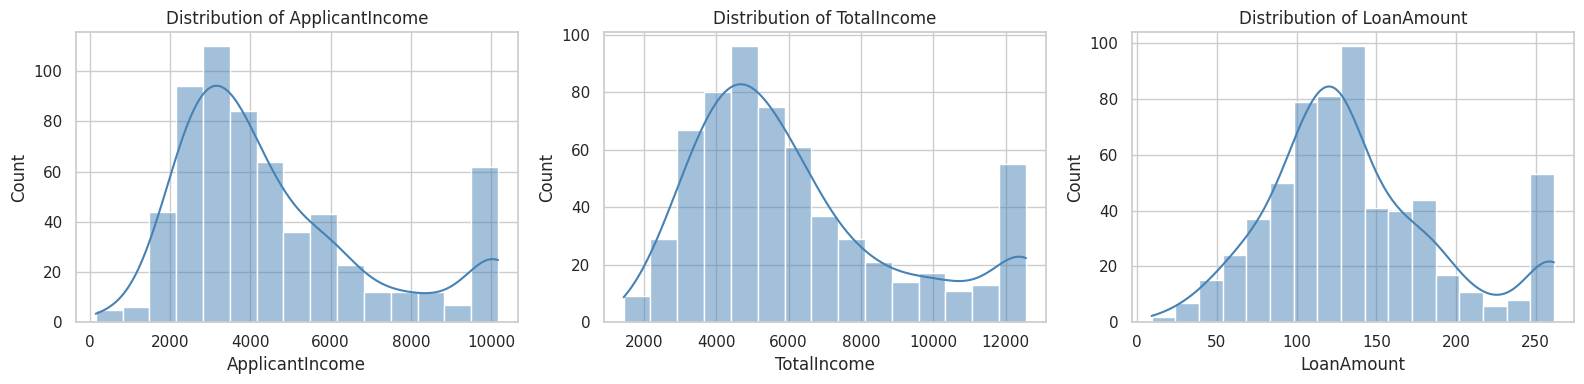

In [ ]:
# Chart 2: Distribution of income and loan amount
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for i, col in enumerate(["ApplicantIncome", "TotalIncome", "LoanAmount"]):
    sns.histplot(clean[col], kde=True, ax=ax[i], color="steelblue")
    ax[i].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

/tmp/ipykernel_2347/3295882185.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Loan_Status", y="TotalIncome", data=clean, ax=ax[0], palette="Set2")
/tmp/ipykernel_2347/3295882185.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Loan_Status", y="LoanAmount", data=clean, ax=ax[1], palette="Set2")


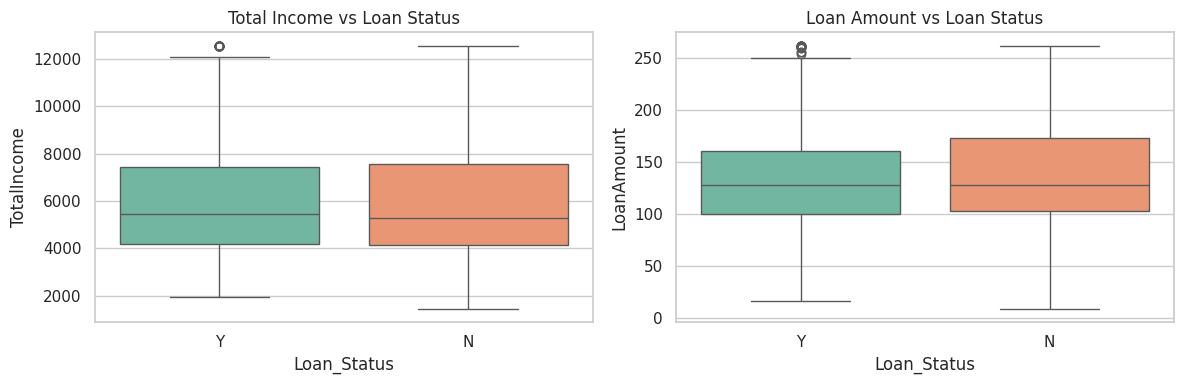

In [ ]:
# Chart 3: Box plots - income and loan amount by loan status
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x="Loan_Status", y="TotalIncome", data=clean, ax=ax[0], palette="Set2")
ax[0].set_title("Total Income vs Loan Status")
sns.boxplot(x="Loan_Status", y="LoanAmount", data=clean, ax=ax[1], palette="Set2")
ax[1].set_title("Loan Amount vs Loan Status")
plt.tight_layout()
plt.show()

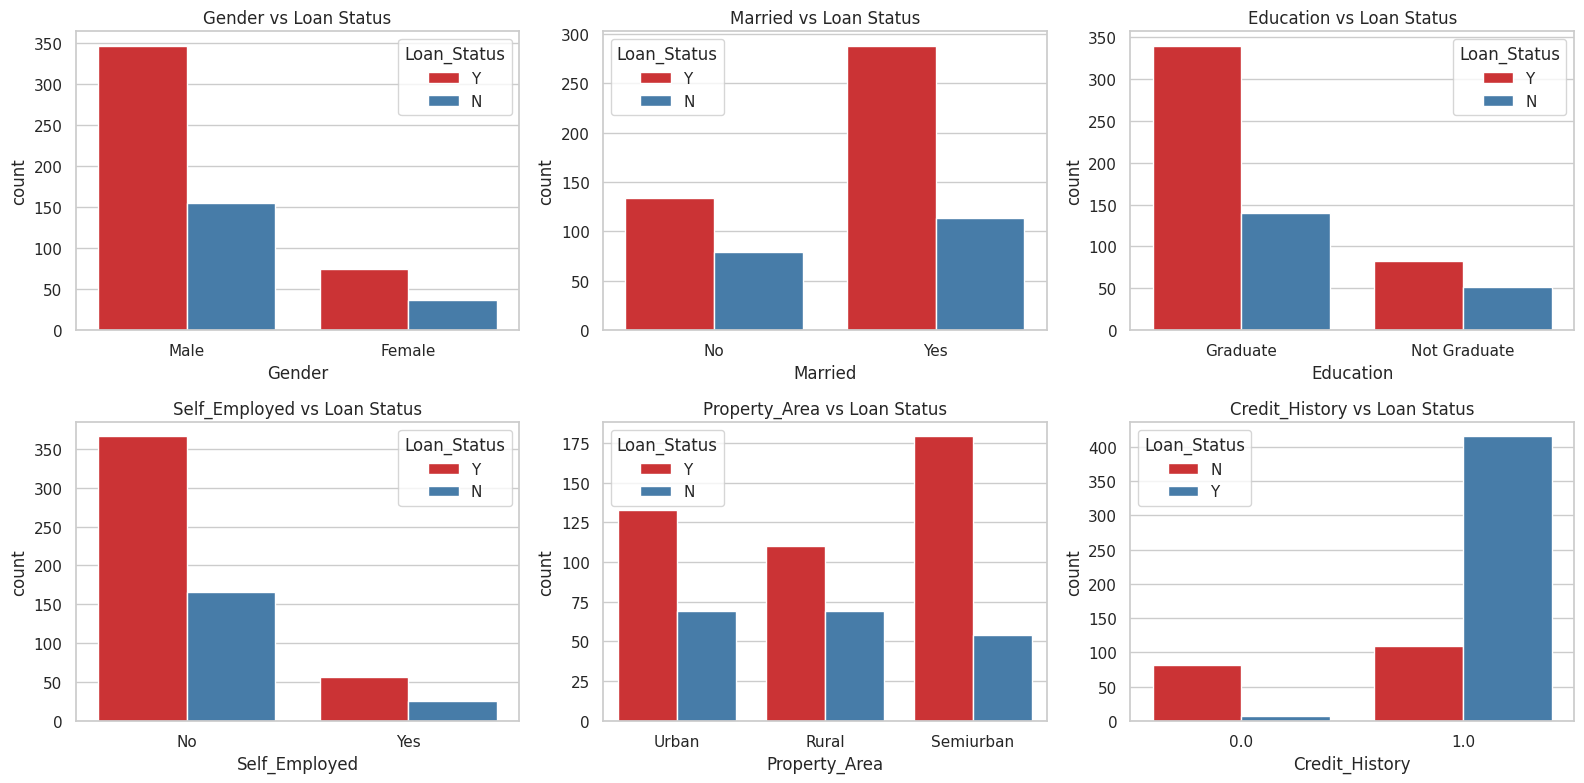

In [ ]:
# Chart 4: Categorical features vs loan status
cols = ["Gender", "Married", "Education", "Self_Employed", "Property_Area", "Credit_History"]
fig, ax = plt.subplots(2, 3, figsize=(16, 8))
for a, col in zip(ax.ravel(), cols):
    sns.countplot(x=col, hue="Loan_Status", data=clean, ax=a, palette="Set1")
    a.set_title(f"{col} vs Loan Status")
plt.tight_layout()
plt.show()

/tmp/ipykernel_2347/762240603.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Credit_History", y="Approved", data=clean, ax=ax[0], palette="Blues")
/tmp/ipykernel_2347/762240603.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Property_Area", y="Approved", data=clean, ax=ax[1], palette="Greens")


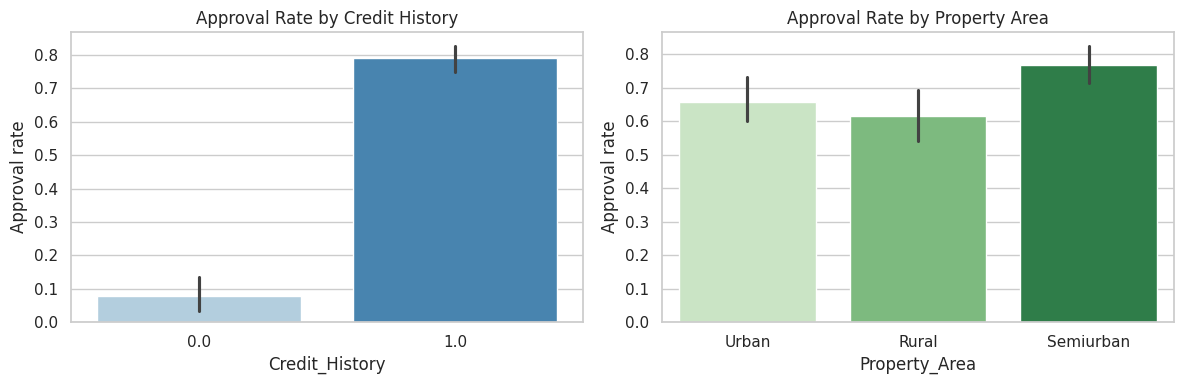

In [ ]:
# Chart 5: Approval rate by credit history and property area (key trend)
clean["Approved"] = (clean["Loan_Status"] == "Y").astype(int)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x="Credit_History", y="Approved", data=clean, ax=ax[0], palette="Blues")
ax[0].set_title("Approval Rate by Credit History")
ax[0].set_ylabel("Approval rate")
sns.barplot(x="Property_Area", y="Approved", data=clean, ax=ax[1], palette="Greens")
ax[1].set_title("Approval Rate by Property Area")
ax[1].set_ylabel("Approval rate")
plt.tight_layout()
plt.show()

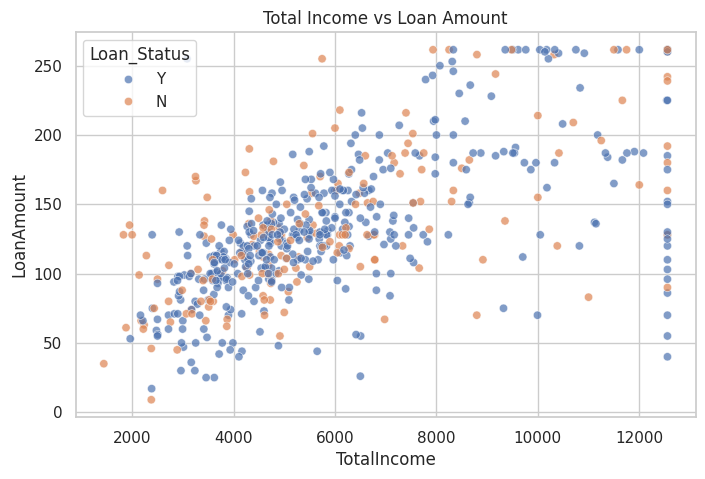

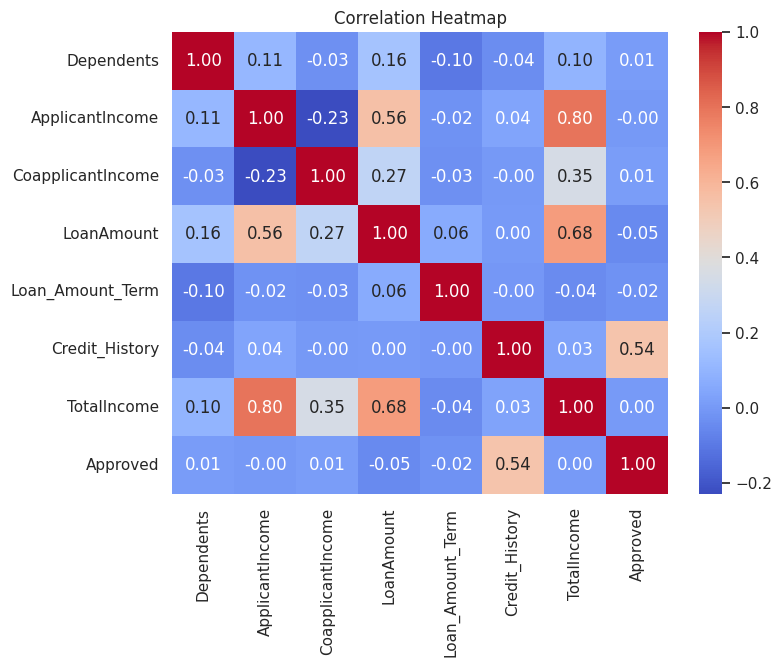

In [ ]:
# Chart 6: Income vs loan amount scatter plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x="TotalIncome", y="LoanAmount", hue="Loan_Status", data=clean, alpha=0.7)
plt.title("Total Income vs Loan Amount")
plt.show()

# Chart 7: Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(clean.select_dtypes(include="number").corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Step 7: Save the cleaned dataset

In [16]:
if "Approved" in clean.columns:
    clean = clean.drop(columns=["Approved"])

clean.to_csv("loan_cleaned.csv", index=False)
files.download("loan_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
import os, subprocess, time, re, urllib.request

!pip install -q streamlit plotly

if not os.path.exists("cloudflared"):
    !wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
    !chmod +x cloudflared

!pkill -f streamlit
!pkill -f cloudflared

subprocess.Popen("streamlit run app.py --server.port 8501 --server.headless true > logs.txt 2>&1", shell=True)
time.sleep(15)
print(urllib.request.urlopen("http://localhost:8501/_stcore/health").read())

subprocess.Popen("./cloudflared tunnel --url http://localhost:8501 > cf.log 2>&1", shell=True)
time.sleep(10)
print(re.findall(r"https://[a-z0-9-]+\.trycloudflare\.com", open("cf.log").read()))

b'ok'
['https://groundwater-taylor-processor-gave.trycloudflare.com']
